# XL-Sum Dataset Analysis Pipeline

Bu notebook, bitirme raporu icin `csebuetnlp/xlsum` veri setinin dil/split bazli istatistiklerini uretir. Google Colab'de bastan sona calistirilacak sekilde hazirlanmistir.

Urettigi baslica ciktlar:

- hedef dil planı ve public XL-Sum subset uygunlugu
- train/validation/test ornek sayilari
- makale, ozet ve baslik uzunluk istatistikleri
- ozetleme sikistirma orani
- bos alan ve duplicate kontrolleri
- kaynak-ozet overlap, novelty ve extractiveness proxy metrikleri
- CSV, Excel ve PNG rapor dosyalari


In [1]:
# Colab kurulumu
# Not: numpy/pandas/scipy gibi C-extension paketleri ayni runtime icinde degistiginde
# ABI uyumsuzlugu olusabilir. Bu hucre paketleri uyumlu surumlerle force-reinstall eder
# ve Colab runtime'ini bir kez yeniden baslatir. Yeniden baslatmadan sonra Run all yapin.
import os
import sys
import subprocess

MARKER_PATH = "/content/.xlsum_dataset_analysis_deps_installed"
PACKAGES = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "matplotlib==3.8.4",
    "seaborn==0.13.2",
    "scipy==1.13.1",
    "datasets>=2.20,<3",
    "openpyxl>=3.1",
    "tqdm>=4.66",
    "regex>=2024.5",
    "tabulate>=0.9",
]

if os.path.exists("/content") and not os.path.exists(MARKER_PATH):
    print("Installing compatible analysis dependencies...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        "--force-reinstall",
        *PACKAGES,
    ])
    with open(MARKER_PATH, "w", encoding="utf-8") as f:
        f.write("installed\n")
    print("Dependencies installed. Runtime will restart now. After restart, run all cells again.")
    os.kill(os.getpid(), 9)
else:
    print("Dependency setup already completed for this runtime.")

Dependency setup already completed for this runtime.


In [2]:
from pathlib import Path
from datetime import datetime
from collections import Counter
import json
import math
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, get_dataset_config_names
from IPython.display import display, Markdown
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

print({
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "seaborn": sns.__version__,
})

{'python': '3.12.13', 'numpy': '1.26.4', 'pandas': '2.2.2', 'seaborn': '0.13.2'}


## 1. Ayarlar

`TARGET_LANGUAGES` proje raporundaki 15 dilli deney planini temsil eder. Public `csebuetnlp/xlsum` paketinde karsiligi olmayan diller otomatik olarak `skipped_no_xlsum_subset` durumuna alinir.

Performans notu: `TEXT_STATS_SAMPLE_PER_SPLIT = None` tum satirlari analiz eder. Colab suresi kisitliysa once `5000` veya `10000` ile deneyebilirsiniz.

In [3]:
# Google Drive'a yazmak isterseniz True yapin.
MOUNT_DRIVE = False
DRIVE_OUTPUT_ROOT = "/content/drive/MyDrive/inf494_projet/evaluation/dataset_analysis"

# None: tum veri. Orneklemle hizli analiz icin orn. 10000 yapabilirsiniz.
TEXT_STATS_SAMPLE_PER_SPLIT = None

# Overlap/novelty metrikleri daha maliyetli oldugu icin varsayilan olarak split basina orneklenir.
# Tam hesaplamak icin None yapin.
OVERLAP_SAMPLE_PER_SPLIT = 2000

RANDOM_SEED = 42
DATASET_NAME = "csebuetnlp/xlsum"
SPLITS = ["train", "validation", "test"]

TARGET_LANGUAGES = ["en", "tr", "fr", "de", "es", "it", "ru", "ar", "hi", "zh", "ja", "ko", "nl", "ro", "vi"]

LANGUAGE_CONFIGS = {
    "en": {"name": "English", "xlsum_subset": "english"},
    "tr": {"name": "Turkish", "xlsum_subset": "turkish"},
    "fr": {"name": "French", "xlsum_subset": "french"},
    "de": {"name": "German", "xlsum_subset": "german"},
    "es": {"name": "Spanish", "xlsum_subset": "spanish"},
    "it": {"name": "Italian", "xlsum_subset": "italian"},
    "ru": {"name": "Russian", "xlsum_subset": "russian"},
    "ar": {"name": "Arabic", "xlsum_subset": "arabic"},
    "hi": {"name": "Hindi", "xlsum_subset": "hindi"},
    "zh": {"name": "Chinese Simplified", "xlsum_subset": "chinese_simplified"},
    "ja": {"name": "Japanese", "xlsum_subset": "japanese"},
    "ko": {"name": "Korean", "xlsum_subset": "korean"},
    "nl": {"name": "Dutch", "xlsum_subset": "dutch"},
    "ro": {"name": "Romanian", "xlsum_subset": "romanian"},
    "vi": {"name": "Vietnamese", "xlsum_subset": "vietnamese"},
}

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = Path(DRIVE_OUTPUT_ROOT) / f"xlsum_dataset_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
else:
    OUTPUT_DIR = Path("/content") / f"xlsum_dataset_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/xlsum_dataset_analysis_20260518_154155


## 2. Yardimci Fonksiyonlar

In [4]:
CJK_RE = re.compile(r"[\u3400-\u4dbf\u4e00-\u9fff\uf900-\ufaff\u3040-\u30ff\uac00-\ud7af]")
WORD_RE = re.compile(r"[\w]+", flags=re.UNICODE)

def normalize_text(value):
    if value is None:
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

def char_count(value):
    return len(normalize_text(value))

def token_like_count(value):
    """Dil bağımsız yaklaşık uzunluk: CJK karakterlerini ve Unicode word tokenlarini birlikte sayar."""
    text = normalize_text(value).lower()
    if not text:
        return 0
    cjk = CJK_RE.findall(text)
    without_cjk = CJK_RE.sub(" ", text)
    words = WORD_RE.findall(without_cjk)
    return len(cjk) + len(words)

def tokenize_for_overlap(value):
    text = normalize_text(value).lower()
    cjk = CJK_RE.findall(text)
    without_cjk = CJK_RE.sub(" ", text)
    words = WORD_RE.findall(without_cjk)
    return words + cjk

def ngrams(tokens, n):
    if len(tokens) < n:
        return set()
    return set(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def safe_divide(num, den):
    return np.nan if den == 0 else num / den

def duplicate_nonempty_count(values):
    counts = Counter(x for x in values if x)
    return sum(count - 1 for count in counts.values() if count > 1)

def describe_numeric(series, prefix):
    s = pd.Series(series).dropna()
    if s.empty:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_p25": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_p75": np.nan,
            f"{prefix}_p90": np.nan,
            f"{prefix}_p95": np.nan,
            f"{prefix}_max": np.nan,
        }
    return {
        f"{prefix}_mean": float(s.mean()),
        f"{prefix}_std": float(s.std(ddof=1)) if len(s) > 1 else 0.0,
        f"{prefix}_min": float(s.min()),
        f"{prefix}_p25": float(s.quantile(0.25)),
        f"{prefix}_median": float(s.median()),
        f"{prefix}_p75": float(s.quantile(0.75)),
        f"{prefix}_p90": float(s.quantile(0.90)),
        f"{prefix}_p95": float(s.quantile(0.95)),
        f"{prefix}_max": float(s.max()),
    }

def select_for_analysis(ds, limit, seed=RANDOM_SEED):
    if limit is None or len(ds) <= limit:
        return ds, len(ds), False
    sampled = ds.shuffle(seed=seed).select(range(limit))
    return sampled, limit, True

def save_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def write_csv(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)

## 3. Public XL-Sum Subset Kontrolu

In [5]:
try:
    available_configs = set(get_dataset_config_names(DATASET_NAME, trust_remote_code=True))
except TypeError:
    available_configs = set(get_dataset_config_names(DATASET_NAME))

plan_rows = []
for lang in TARGET_LANGUAGES:
    cfg = LANGUAGE_CONFIGS[lang]
    subset = cfg["xlsum_subset"]
    exists = subset in available_configs
    plan_rows.append({
        "language": lang,
        "language_name": cfg["name"],
        "xlsum_subset": subset,
        "status": "run" if exists else "skipped_no_xlsum_subset",
    })

language_plan_df = pd.DataFrame(plan_rows)
RUN_LANGUAGES = language_plan_df.loc[language_plan_df["status"] == "run", "language"].tolist()

display(language_plan_df)
print("Runnable languages:", RUN_LANGUAGES)
write_csv(language_plan_df, "language_plan.csv")

,language,language_name,xlsum_subset,status
0,en,English,english,run
1,tr,Turkish,turkish,run
2,fr,French,french,run
3,de,German,german,skipped_no_xlsum_subset
4,es,Spanish,spanish,run
5,it,Italian,italian,skipped_no_xlsum_subset
6,ru,Russian,russian,run
7,ar,Arabic,arabic,run
8,hi,Hindi,hindi,run
9,zh,Chinese Simplified,chinese_simplified,run


Runnable languages: ['en', 'tr', 'fr', 'es', 'ru', 'ar', 'hi', 'zh', 'ja', 'ko', 'vi']
Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/language_plan.csv


## 4. Veri Setini Yukleme ve Temel Sayimlar

Bu hucre her calistirilabilir XL-Sum subset'ini yukler. Sayimlar tam veri uzerinden hesaplanir.

In [6]:
datasets_by_lang = {}
count_rows = []
feature_rows = []

for lang in tqdm(RUN_LANGUAGES, desc="Loading XL-Sum subsets"):
    subset = LANGUAGE_CONFIGS[lang]["xlsum_subset"]
    try:
        ds_dict = load_dataset(DATASET_NAME, subset, trust_remote_code=True)
    except TypeError:
        ds_dict = load_dataset(DATASET_NAME, subset)
    datasets_by_lang[lang] = ds_dict

    for split in SPLITS:
        ds = ds_dict[split]
        count_rows.append({
            "language": lang,
            "language_name": LANGUAGE_CONFIGS[lang]["name"],
            "xlsum_subset": subset,
            "split": split,
            "row_count": len(ds),
        })
        feature_rows.append({
            "language": lang,
            "split": split,
            "features": ", ".join(ds.column_names),
        })

dataset_counts_df = pd.DataFrame(count_rows)
dataset_features_df = pd.DataFrame(feature_rows)
dataset_counts_df["split_total"] = dataset_counts_df.groupby("split")["row_count"].transform("sum")
dataset_counts_df["share_within_split"] = dataset_counts_df["row_count"] / dataset_counts_df["split_total"]

display(dataset_counts_df.sort_values(["split", "row_count"], ascending=[True, False]))
display(dataset_features_df.head())
write_csv(dataset_counts_df, "dataset_counts.csv")
write_csv(dataset_features_df, "dataset_features.csv")

Loading XL-Sum subsets:   0%|          | 0/11 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

,language,language_name,xlsum_subset,split,row_count,split_total,share_within_split
2,en,English,english,test,11535,52219,0.220897
20,hi,Hindi,hindi,test,8847,52219,0.169421
14,ru,Russian,russian,test,7780,52219,0.148988
11,es,Spanish,spanish,test,4763,52219,0.091212
17,ar,Arabic,arabic,test,4689,52219,0.089795
23,zh,Chinese Simplified,chinese_simplified,test,4670,52219,0.089431
32,vi,Vietnamese,vietnamese,test,4013,52219,0.076849
5,tr,Turkish,turkish,test,3397,52219,0.065053
8,fr,French,french,test,1086,52219,0.020797
26,ja,Japanese,japanese,test,889,52219,0.017024


,language,split,features
0,en,train,"id, url, title, summary, text"
1,en,validation,"id, url, title, summary, text"
2,en,test,"id, url, title, summary, text"
3,tr,train,"id, url, title, summary, text"
4,tr,validation,"id, url, title, summary, text"


Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/dataset_counts.csv
Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/dataset_features.csv


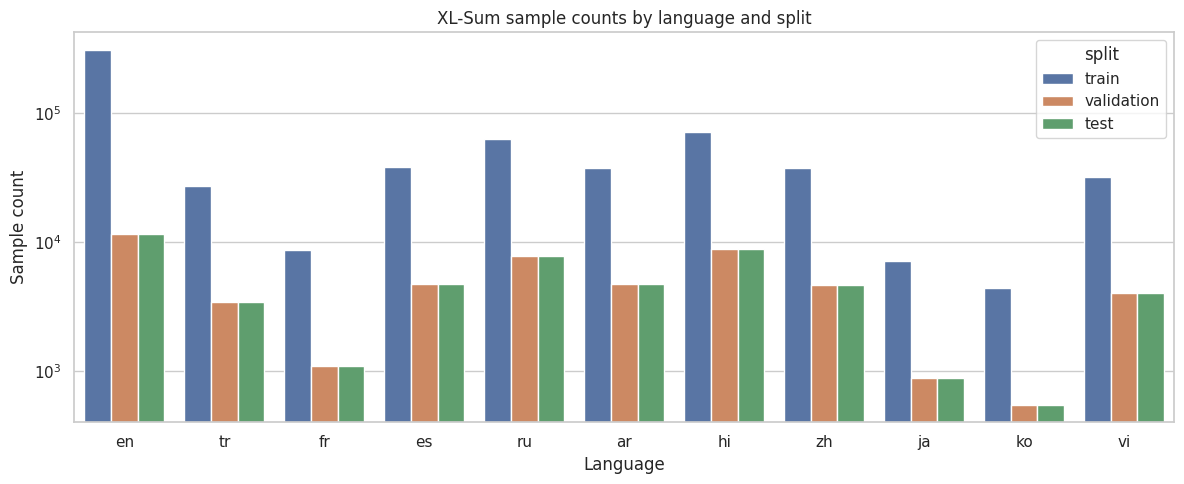

Saved: /content/xlsum_dataset_analysis_20260518_154155/figures/sample_counts_by_language_split.png


In [7]:
plt.figure(figsize=(12, 5))
plot_df = dataset_counts_df.copy()
sns.barplot(data=plot_df, x="language", y="row_count", hue="split")
plt.title("XL-Sum sample counts by language and split")
plt.xlabel("Language")
plt.ylabel("Sample count")
plt.yscale("log")
save_fig("sample_counts_by_language_split.png")

## 5. Uzunluk, Bos Alan ve Duplicate Analizi

Makale (`text`), referans ozet (`summary`) ve baslik (`title`) icin karakter ve yaklasik token/sözcük uzunluklari hesaplanir. Cince/Japonca/Korece icin CJK karakterleri de token benzeri birim olarak sayilir.

In [8]:
length_summary_rows = []
quality_rows = []
sampled_metric_frames = []

for lang in tqdm(RUN_LANGUAGES, desc="Computing length and quality stats"):
    for split in SPLITS:
        ds = datasets_by_lang[lang][split]
        analysis_ds, analyzed_rows, sampled = select_for_analysis(ds, TEXT_STATS_SAMPLE_PER_SPLIT)

        records = []
        missing = Counter()
        ids, urls, texts = [], [], []

        for ex in analysis_ds:
            text = normalize_text(ex.get("text", ""))
            summary = normalize_text(ex.get("summary", ""))
            title = normalize_text(ex.get("title", ""))
            url = normalize_text(ex.get("url", ""))
            ex_id = normalize_text(ex.get("id", ""))

            for field, value in [("text", text), ("summary", summary), ("title", title), ("url", url), ("id", ex_id)]:
                if not value:
                    missing[field] += 1

            ids.append(ex_id)
            urls.append(url)
            texts.append(text)

            text_tokens = token_like_count(text)
            summary_tokens = token_like_count(summary)
            title_tokens = token_like_count(title)
            text_chars = char_count(text)
            summary_chars = char_count(summary)
            title_chars = char_count(title)

            records.append({
                "language": lang,
                "language_name": LANGUAGE_CONFIGS[lang]["name"],
                "split": split,
                "text_chars": text_chars,
                "summary_chars": summary_chars,
                "title_chars": title_chars,
                "text_tokens": text_tokens,
                "summary_tokens": summary_tokens,
                "title_tokens": title_tokens,
                "compression_ratio_tokens": safe_divide(summary_tokens, text_tokens),
                "compression_ratio_chars": safe_divide(summary_chars, text_chars),
            })

        metrics_df = pd.DataFrame(records)
        sampled_metric_frames.append(metrics_df)

        row = {
            "language": lang,
            "language_name": LANGUAGE_CONFIGS[lang]["name"],
            "split": split,
            "dataset_rows": len(ds),
            "analyzed_rows": analyzed_rows,
            "sampled": sampled,
        }
        for col in ["text_chars", "summary_chars", "title_chars", "text_tokens", "summary_tokens", "title_tokens", "compression_ratio_tokens", "compression_ratio_chars"]:
            row.update(describe_numeric(metrics_df[col], col))
        length_summary_rows.append(row)

        quality_rows.append({
            "language": lang,
            "language_name": LANGUAGE_CONFIGS[lang]["name"],
            "split": split,
            "dataset_rows": len(ds),
            "analyzed_rows": analyzed_rows,
            "sampled": sampled,
            "missing_text": missing["text"],
            "missing_summary": missing["summary"],
            "missing_title": missing["title"],
            "missing_url": missing["url"],
            "missing_id": missing["id"],
            "duplicate_id_count": duplicate_nonempty_count(ids),
            "duplicate_url_count": duplicate_nonempty_count(urls),
            "duplicate_text_count": duplicate_nonempty_count(texts),
        })

length_summary_df = pd.DataFrame(length_summary_rows)
quality_df = pd.DataFrame(quality_rows)
sampled_metrics_df = pd.concat(sampled_metric_frames, ignore_index=True)

display(length_summary_df.head())
display(quality_df.head())
write_csv(length_summary_df, "length_summary.csv")
write_csv(quality_df, "data_quality_summary.csv")
write_csv(sampled_metrics_df, "row_level_length_metrics_sample.csv")

Computing length and quality stats:   0%|          | 0/11 [00:00<?, ?it/s]

,language,language_name,split,dataset_rows,analyzed_rows,sampled,text_chars_mean,text_chars_std,text_chars_min,text_chars_p25,text_chars_median,text_chars_p75,text_chars_p90,text_chars_p95,text_chars_max,summary_chars_mean,summary_chars_std,summary_chars_min,summary_chars_p25,summary_chars_median,summary_chars_p75,summary_chars_p90,summary_chars_p95,summary_chars_max,title_chars_mean,title_chars_std,title_chars_min,title_chars_p25,title_chars_median,title_chars_p75,title_chars_p90,title_chars_p95,title_chars_max,text_tokens_mean,text_tokens_std,text_tokens_min,text_tokens_p25,text_tokens_median,text_tokens_p75,text_tokens_p90,text_tokens_p95,text_tokens_max,summary_tokens_mean,summary_tokens_std,summary_tokens_min,summary_tokens_p25,summary_tokens_median,summary_tokens_p75,summary_tokens_p90,summary_tokens_p95,summary_tokens_max,title_tokens_mean,title_tokens_std,title_tokens_min,title_tokens_p25,title_tokens_median,title_tokens_p75,title_tokens_p90,title_tokens_p95,title_tokens_max,compression_ratio_tokens_mean,compression_ratio_tokens_std,compression_ratio_tokens_min,compression_ratio_tokens_p25,compression_ratio_tokens_median,compression_ratio_tokens_p75,compression_ratio_tokens_p90,compression_ratio_tokens_p95,compression_ratio_tokens_max,compression_ratio_chars_mean,compression_ratio_chars_std,compression_ratio_chars_min,compression_ratio_chars_p25,compression_ratio_chars_median,compression_ratio_chars_p75,compression_ratio_chars_p90,compression_ratio_chars_p95,compression_ratio_chars_max
0,en,English,train,306522,306522,False,2736.186652,2087.411035,34.0,1435.0,2185.0,3599.0,5188.0,6187.0,234745.0,130.842507,42.414851,4.0,106.0,128.0,146.0,171.0,198.0,968.0,52.512962,9.604381,8.0,47.0,53.0,58.0,64.0,68.0,112.0,471.853113,364.961863,7.0,246.0,375.0,619.0,898.0,1072.0,40525.0,22.690861,7.426271,1.0,18.0,22.0,25.0,30.0,35.0,170.0,8.417872,1.774366,1.0,7.0,8.0,10.0,11.0,11.0,21.0,0.072196,0.056311,0.000231,0.036969,0.057823,0.087649,0.131148,0.175676,1.052632,0.071007,0.053924,0.000415,0.037118,0.057606,0.086294,0.127993,0.169984,1.027523
1,en,English,validation,11535,11535,False,2612.896749,1567.214988,355.0,1470.5,2153.0,3421.5,4883.0,5719.6,10107.0,125.227308,27.168705,46.0,106.0,126.0,144.0,155.0,174.0,246.0,52.803208,9.410136,14.0,48.0,53.0,58.0,64.0,68.0,97.0,449.745644,271.949803,56.0,254.0,369.0,588.0,845.0,996.0,1722.0,21.693195,4.802256,8.0,18.0,22.0,25.0,28.0,30.0,42.0,8.433637,1.773379,2.0,7.0,8.0,10.0,11.0,11.0,17.0,0.065716,0.038236,0.006441,0.037106,0.057143,0.084835,0.120000,0.143085,0.232759,0.064826,0.036815,0.007027,0.037184,0.056564,0.083199,0.116868,0.140531,0.246575
2,en,English,test,11535,11535,False,2595.275769,1540.745718,356.0,1468.0,2140.0,3407.5,4825.6,5694.2,9990.0,125.847941,27.220489,37.0,107.0,127.0,144.0,156.0,174.0,254.0,52.786389,9.415406,12.0,47.0,53.0,58.0,64.0,68.0,96.0,446.649502,267.531955,63.0,251.0,367.0,585.0,831.0,987.0,1720.0,21.788383,4.823326,8.0,18.0,22.0,25.0,28.0,30.0,42.0,8.439965,1.755177,2.0,7.0,8.0,10.0,11.0,11.0,18.0,0.065984,0.037824,0.006294,0.037433,0.057762,0.085227,0.118644,0.142857,0.233766,0.065095,0.036360,0.007007,0.037422,0.057377,0.083586,0.115659,0.139292,0.232432
3,tr,Turkish,train,27176,27176,False,3094.114071,2559.742325,119.0,1486.0,2263.0,3842.0,6150.5,8062.5,39334.0,178.055159,71.382370,4.0,130.0,166.0,212.0,270.0,313.0,1010.0,61.314248,22.616231,14.0,44.0,56.0,76.0,94.0,105.0,163.0,417.472476,349.779400,18.0,199.0,303.0,519.0,835.0,1093.0,5401.0,24.279143,9.855576,1.0,18.0,22.0,29.0,37.0,43.0,146.0,8.874926,3.196467,2.0,6.0,8.0,11.0,13.0,15.0,23.0,0.088468,0.063603,0.000725,0.044464,0.074150,0.114286,0.164706,0.207317,0.625000,0.087040,0.061749,0.000498,0.044021,0.073245,0.112547,0.161639,0.202680,0.510769
4,tr,Turkish,validation,3397,3397,False,2818.216956,1749.415650,462.0,1534.0,2269.0,3623.0,5360.4,6611.8,9497.0,166.405063,51.546103,53.0,129.0,160.0,200.0,240.0,263.0,324.0,60.111275,21.840491,16.0,44.0,55.0,74.0,92.0,102.0,148.0,379.510745,237.8753

,language,language_name,split,dataset_rows,analyzed_rows,sampled,missing_text,missing_summary,missing_title,missing_url,missing_id,duplicate_id_count,duplicate_url_count,duplicate_text_count
0,en,English,train,306522,306522,False,0,0,0,0,0,0,0,29
1,en,English,validation,11535,11535,False,0,0,0,0,0,0,0,0
2,en,English,test,11535,11535,False,0,0,0,0,0,0,0,0
3,tr,Turkish,train,27176,27176,False,0,0,0,0,0,0,0,3
4,tr,Turkish,validation,3397,3397,False,0,0,0,0,0,0,0,0


Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/length_summary.csv
Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/data_quality_summary.csv
Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/row_level_length_metrics_sample.csv


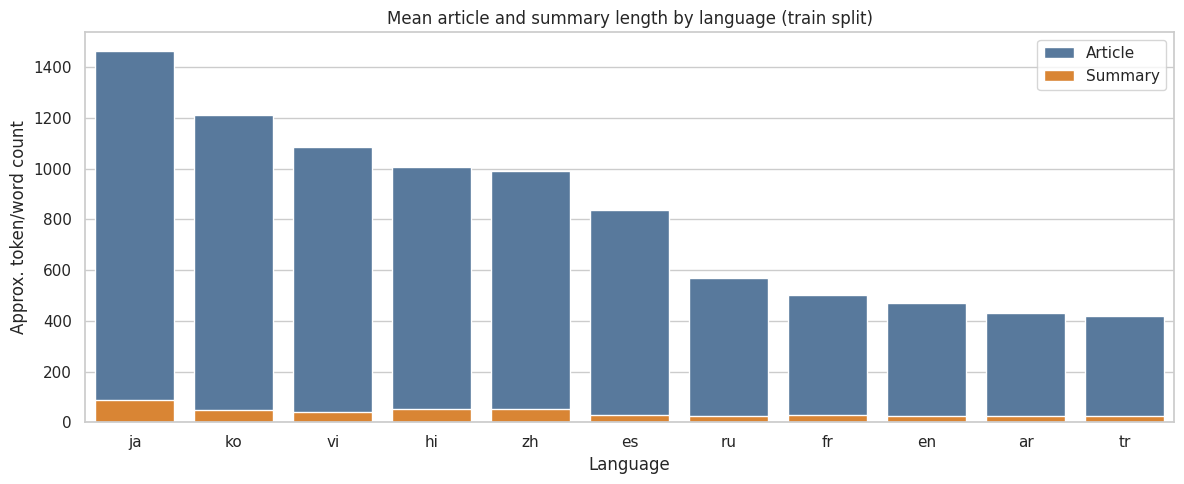

Saved: /content/xlsum_dataset_analysis_20260518_154155/figures/mean_article_summary_length_train.png


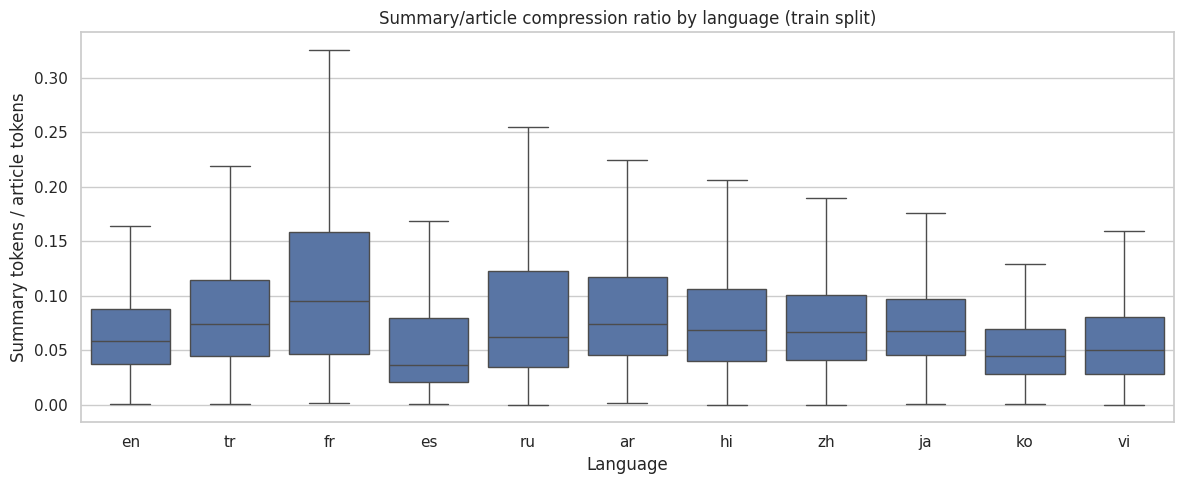

Saved: /content/xlsum_dataset_analysis_20260518_154155/figures/compression_ratio_boxplot_train.png


In [9]:
train_lengths = length_summary_df[length_summary_df["split"] == "train"].sort_values("text_tokens_mean", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=train_lengths, x="language", y="text_tokens_mean", color="#4C78A8", label="Article")
sns.barplot(data=train_lengths, x="language", y="summary_tokens_mean", color="#F58518", label="Summary")
plt.title("Mean article and summary length by language (train split)")
plt.xlabel("Language")
plt.ylabel("Approx. token/word count")
plt.legend()
save_fig("mean_article_summary_length_train.png")

plt.figure(figsize=(12, 5))
sns.boxplot(data=sampled_metrics_df[sampled_metrics_df["split"] == "train"], x="language", y="compression_ratio_tokens", showfliers=False)
plt.title("Summary/article compression ratio by language (train split)")
plt.xlabel("Language")
plt.ylabel("Summary tokens / article tokens")
save_fig("compression_ratio_boxplot_train.png")

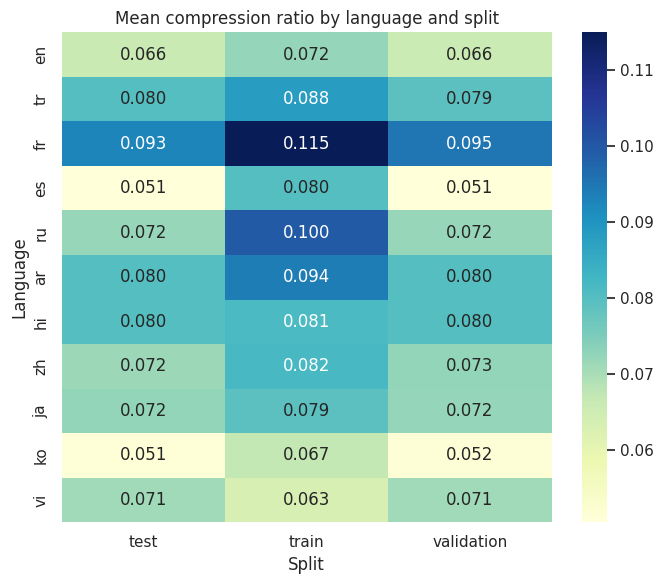

Saved: /content/xlsum_dataset_analysis_20260518_154155/figures/compression_ratio_heatmap.png


In [10]:
heatmap_df = length_summary_df.pivot_table(
    index="language",
    columns="split",
    values="compression_ratio_tokens_mean",
    aggfunc="mean",
).reindex(RUN_LANGUAGES)

plt.figure(figsize=(7, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Mean compression ratio by language and split")
plt.xlabel("Split")
plt.ylabel("Language")
save_fig("compression_ratio_heatmap.png")

## 6. Kaynak-Ozet Overlap ve Novelty Analizi

Bu bolum rapor icin ozetlerin ne kadar extractive/abstractive olduguna dair proxy metrikler uretir:

- `summary_unigram_source_recall`: ozetteki unigramlarin kaynakta bulunma orani
- `summary_bigram_source_recall`: ozetteki bigramlarin kaynakta bulunma orani
- `novelty_1gram`: kaynakta bulunmayan ozet unigram orani
- `novelty_2gram`: kaynakta bulunmayan ozet bigram orani

Varsayilan olarak bu metrikler split basina orneklem uzerinden hesaplanir.

In [11]:
overlap_row_frames = []
overlap_summary_rows = []

for lang in tqdm(RUN_LANGUAGES, desc="Computing overlap and novelty stats"):
    for split in SPLITS:
        ds = datasets_by_lang[lang][split]
        analysis_ds, analyzed_rows, sampled = select_for_analysis(ds, OVERLAP_SAMPLE_PER_SPLIT)
        rows = []

        for ex in analysis_ds:
            src_tokens = tokenize_for_overlap(ex.get("text", ""))
            sum_tokens = tokenize_for_overlap(ex.get("summary", ""))
            src_uni = set(src_tokens)
            sum_uni = set(sum_tokens)
            src_bi = ngrams(src_tokens, 2)
            sum_bi = ngrams(sum_tokens, 2)

            uni_overlap = len(sum_uni & src_uni)
            bi_overlap = len(sum_bi & src_bi)

            rows.append({
                "language": lang,
                "language_name": LANGUAGE_CONFIGS[lang]["name"],
                "split": split,
                "summary_unigram_source_recall": safe_divide(uni_overlap, len(sum_uni)),
                "summary_bigram_source_recall": safe_divide(bi_overlap, len(sum_bi)),
                "novelty_1gram": 1 - safe_divide(uni_overlap, len(sum_uni)) if len(sum_uni) else np.nan,
                "novelty_2gram": 1 - safe_divide(bi_overlap, len(sum_bi)) if len(sum_bi) else np.nan,
            })

        overlap_df = pd.DataFrame(rows)
        overlap_row_frames.append(overlap_df)
        summary_row = {
            "language": lang,
            "language_name": LANGUAGE_CONFIGS[lang]["name"],
            "split": split,
            "dataset_rows": len(ds),
            "analyzed_rows": analyzed_rows,
            "sampled": sampled,
        }
        for col in ["summary_unigram_source_recall", "summary_bigram_source_recall", "novelty_1gram", "novelty_2gram"]:
            summary_row.update(describe_numeric(overlap_df[col], col))
        overlap_summary_rows.append(summary_row)

overlap_metrics_df = pd.concat(overlap_row_frames, ignore_index=True)
overlap_summary_df = pd.DataFrame(overlap_summary_rows)

display(overlap_summary_df.head())
write_csv(overlap_summary_df, "overlap_novelty_summary.csv")
write_csv(overlap_metrics_df, "row_level_overlap_metrics_sample.csv")

Computing overlap and novelty stats:   0%|          | 0/11 [00:00<?, ?it/s]

,language,language_name,split,dataset_rows,analyzed_rows,sampled,summary_unigram_source_recall_mean,summary_unigram_source_recall_std,summary_unigram_source_recall_min,summary_unigram_source_recall_p25,summary_unigram_source_recall_median,summary_unigram_source_recall_p75,summary_unigram_source_recall_p90,summary_unigram_source_recall_p95,summary_unigram_source_recall_max,summary_bigram_source_recall_mean,summary_bigram_source_recall_std,summary_bigram_source_recall_min,summary_bigram_source_recall_p25,summary_bigram_source_recall_median,summary_bigram_source_recall_p75,summary_bigram_source_recall_p90,summary_bigram_source_recall_p95,summary_bigram_source_recall_max,novelty_1gram_mean,novelty_1gram_std,novelty_1gram_min,novelty_1gram_p25,novelty_1gram_median,novelty_1gram_p75,novelty_1gram_p90,novelty_1gram_p95,novelty_1gram_max,novelty_2gram_mean,novelty_2gram_std,novelty_2gram_min,novelty_2gram_p25,novelty_2gram_median,novelty_2gram_p75,novelty_2gram_p90,novelty_2gram_p95,novelty_2gram_max
0,en,English,train,306522,2000,True,0.665290,0.144056,0.142857,0.571429,0.677995,0.763545,0.850000,0.884615,1.0,0.197652,0.124494,0.0,0.105263,0.181818,0.272727,0.368616,0.423173,0.636364,0.334710,0.144056,0.0,0.236455,0.322005,0.428571,0.526316,0.592963,0.857143,0.802348,0.124494,0.363636,0.727273,0.818182,0.894737,0.950238,1.0,1.0
1,en,English,validation,11535,2000,True,0.671489,0.134791,0.153846,0.583333,0.680000,0.764706,0.842105,0.882353,1.0,0.198577,0.127439,0.0,0.105263,0.181818,0.273511,0.375000,0.423077,1.000000,0.328511,0.134791,0.0,0.235294,0.320000,0.416667,0.500000,0.555556,0.846154,0.801423,0.127439,0.000000,0.726489,0.818182,0.894737,0.950000,1.0,1.0
2,en,English,test,11535,2000,True,0.670147,0.133391,0.142857,0.583333,0.678571,0.764706,0.833333,0.875000,1.0,0.197626,0.126346,0.0,0.105263,0.181818,0.270105,0.363939,0.428571,1.000000,0.329853,0.133391,0.0,0.235294,0.321429,0.416667,0.500000,0.555556,0.857143,0.802374,0.126346,0.000000,0.729895,0.818182,0.894737,0.947368,1.0,1.0
3,tr,Turkish,train,27176,2000,True,0.503962,0.160431,0.000000,0.391304,0.500000,0.611111,0.703704,0.762045,1.0,0.172625,0.125355,0.0,0.080000,0.153846,0.250000,0.333333,0.411765,0.785714,0.496038,0.160431,0.0,0.388889,0.500000,0.608696,0.707419,0.761905,1.000000,0.827375,0.125355,0.214286,0.750000,0.846154,0.920000,0.970588,1.0,1.0
4,tr,Turkish,validation,3397,2000,True,0.517939,0.155183,0.050000,0.411765,0.517241,0.625000,0.722500,0.777778,1.0,0.180659,0.132853,0.0,0.083333,0.160000,0.250000,0.357143,0.437500,1.000000,0.482061,0.155183,0.0,0.375000,0.482759,0.588235,0.684211,0.733333,0.950000,0.819341,0.132853,0.000000,0.750000,0.840000,0.916667,0.964409,1.0,1.0


Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/overlap_novelty_summary.csv
Saved: /content/xlsum_dataset_analysis_20260518_154155/tables/row_level_overlap_metrics_sample.csv


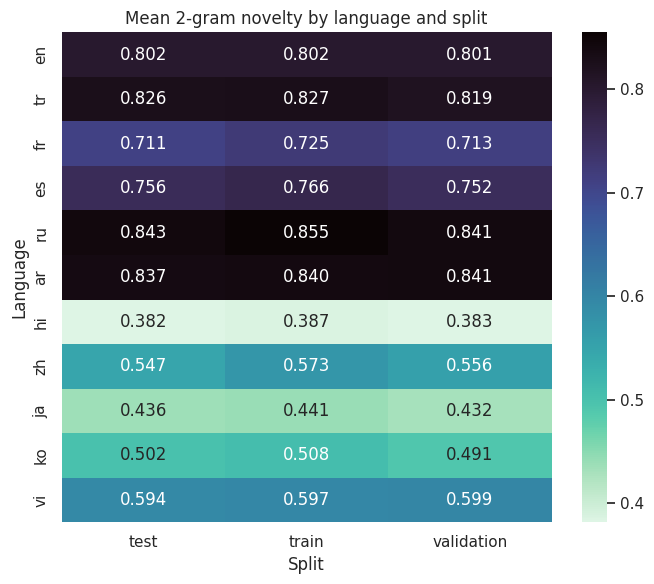

Saved: /content/xlsum_dataset_analysis_20260518_154155/figures/novelty_2gram_heatmap.png


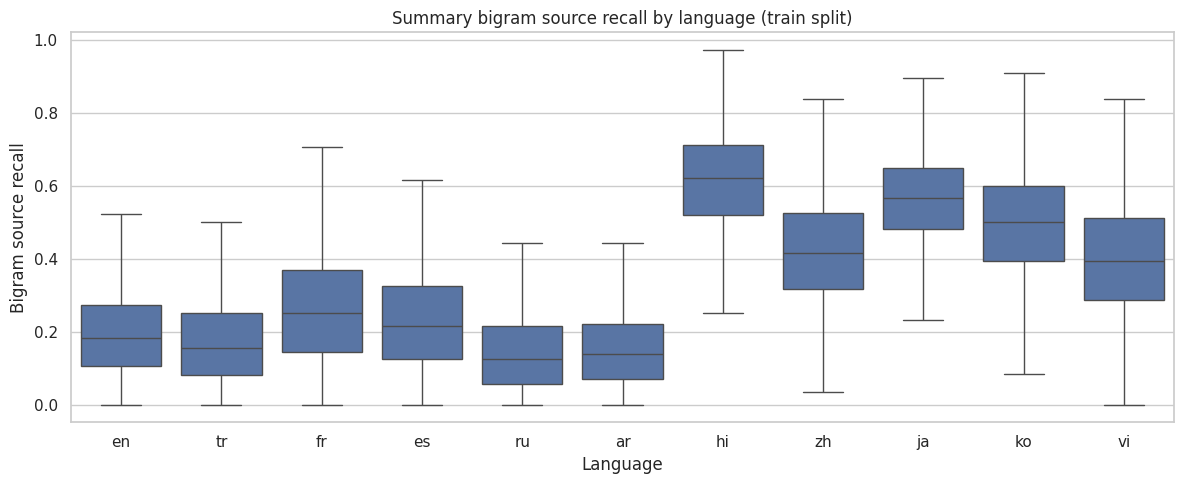

Saved: /content/xlsum_dataset_analysis_20260518_154155/figures/bigram_source_recall_boxplot_train.png


In [12]:
novelty_heatmap = overlap_summary_df.pivot_table(
    index="language",
    columns="split",
    values="novelty_2gram_mean",
    aggfunc="mean",
).reindex(RUN_LANGUAGES)

plt.figure(figsize=(7, 6))
sns.heatmap(novelty_heatmap, annot=True, fmt=".3f", cmap="mako_r")
plt.title("Mean 2-gram novelty by language and split")
plt.xlabel("Split")
plt.ylabel("Language")
save_fig("novelty_2gram_heatmap.png")

plt.figure(figsize=(12, 5))
sns.boxplot(data=overlap_metrics_df[overlap_metrics_df["split"] == "train"], x="language", y="summary_bigram_source_recall", showfliers=False)
plt.title("Summary bigram source recall by language (train split)")
plt.xlabel("Language")
plt.ylabel("Bigram source recall")
save_fig("bigram_source_recall_boxplot_train.png")

## 7. Rapor Ozeti ve Excel Ciktisi

In [13]:
overall_counts = dataset_counts_df.groupby("split", as_index=False)["row_count"].sum()
overall_length = length_summary_df.groupby("split", as_index=False).agg(
    analyzed_rows=("analyzed_rows", "sum"),
    mean_article_tokens=("text_tokens_mean", "mean"),
    mean_summary_tokens=("summary_tokens_mean", "mean"),
    mean_compression_ratio=("compression_ratio_tokens_mean", "mean"),
)
overall_overlap = overlap_summary_df.groupby("split", as_index=False).agg(
    analyzed_rows=("analyzed_rows", "sum"),
    mean_unigram_source_recall=("summary_unigram_source_recall_mean", "mean"),
    mean_bigram_source_recall=("summary_bigram_source_recall_mean", "mean"),
    mean_novelty_1gram=("novelty_1gram_mean", "mean"),
    mean_novelty_2gram=("novelty_2gram_mean", "mean"),
)

excel_path = OUTPUT_DIR / "xlsum_dataset_analysis_report.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    language_plan_df.to_excel(writer, sheet_name="language_plan", index=False)
    dataset_counts_df.to_excel(writer, sheet_name="dataset_counts", index=False)
    dataset_features_df.to_excel(writer, sheet_name="dataset_features", index=False)
    length_summary_df.to_excel(writer, sheet_name="length_summary", index=False)
    quality_df.to_excel(writer, sheet_name="data_quality", index=False)
    overlap_summary_df.to_excel(writer, sheet_name="overlap_novelty", index=False)
    overall_counts.to_excel(writer, sheet_name="overall_counts", index=False)
    overall_length.to_excel(writer, sheet_name="overall_length", index=False)
    overall_overlap.to_excel(writer, sheet_name="overall_overlap", index=False)

summary_md = f"""
### XL-Sum Dataset Analysis Summary

- Target languages: {len(TARGET_LANGUAGES)}
- Runnable public XL-Sum subsets: {len(RUN_LANGUAGES)}
- Skipped languages: {', '.join(language_plan_df.loc[language_plan_df['status'] != 'run', 'language'].tolist()) or 'none'}
- Output directory: `{OUTPUT_DIR}`
- Excel report: `{excel_path}`

#### Total samples by split
{overall_counts.to_markdown(index=False)}

#### Macro average length/compression by split
{overall_length.round(3).to_markdown(index=False)}

#### Macro average overlap/novelty by split
{overall_overlap.round(3).to_markdown(index=False)}
"""

summary_path = OUTPUT_DIR / "report_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")

display(Markdown(summary_md))
print("Saved Excel:", excel_path)
print("Saved Markdown:", summary_path)


### XL-Sum Dataset Analysis Summary

- Target languages: 15
- Runnable public XL-Sum subsets: 11
- Skipped languages: de, it, nl, ro
- Output directory: `/content/xlsum_dataset_analysis_20260518_154155`
- Excel report: `/content/xlsum_dataset_analysis_20260518_154155/xlsum_dataset_analysis_report.xlsx`

#### Total samples by split
| split      |   row_count |
|:-----------|------------:|
| test       |       52219 |
| train      |      632038 |
| validation |       52219 |

#### Macro average length/compression by split
| split      |   analyzed_rows |   mean_article_tokens |   mean_summary_tokens |   mean_compression_ratio |
|:-----------|----------------:|----------------------:|----------------------:|-------------------------:|
| test       |           52219 |               697.318 |                37.135 |                    0.072 |
| train      |          632038 |               816.777 |                39.228 |                    0.084 |
| validation |           52219 |               695.923 |                37.084 |                    0.072 |

#### Macro average overlap/novelty by split
| split      |   analyzed_rows |   mean_unigram_source_recall |   mean_bigram_source_recall |   mean_novelty_1gram |   mean_novelty_2gram |
|:-----------|----------------:|-----------------------------:|----------------------------:|---------------------:|---------------------:|
| test       |           18525 |                        0.708 |                       0.342 |                0.292 |                0.658 |
| train      |           22000 |                        0.697 |                       0.334 |                0.303 |                0.666 |
| validation |           18525 |                        0.708 |                       0.343 |                0.292 |                0.657 |


Saved Excel: /content/xlsum_dataset_analysis_20260518_154155/xlsum_dataset_analysis_report.xlsx
Saved Markdown: /content/xlsum_dataset_analysis_20260518_154155/report_summary.md
